# OLS cross-validation and model selection

This notebook uses NumPy to build K-fold splits for ordinary least squares (OLS). We compare pre-specified variable combinations using out-of-sample mean squared error (MSE), then discuss two limits of cross-validation: target leakage and the optimistic bias that can arise when the same scores are used to select and report a model.

## The data

The `statecrime` dataset is bundled with `statsmodels` and contains 51 state-level observations. We predict `murder`, the murder rate per 100,000 people. The candidate predictors are socioeconomic and urbanization measures. The `white` column is not used here because it is not needed for the model-selection lesson.

The `violent` column is kept for a later warning: the violent-crime rate includes murder by definition, so using it to predict `murder` leaks information from the target into the predictors.

In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.datasets import statecrime

data = statecrime.load_pandas().data.copy()
target = "murder"
predictors = ["poverty", "hs_grad", "single", "urban"]

print(data.shape)
print(data[[target, *predictors]].head())

(51, 7)
            murder  poverty  hs_grad  single  urban
state                                              
Alabama        7.1     17.5     82.1    29.0  48.65
Alaska         3.2      9.0     91.4    25.5  44.46
Arizona        5.5     16.5     84.2    25.7  80.07
Arkansas       6.3     18.8     82.4    26.3  39.54
California     5.4     14.2     80.6    27.8  89.73


## Create the folds with NumPy

We use one fixed random permutation for every candidate model. Each observation appears in exactly one validation fold, and the same folds are reused across models so that their MSEs are directly comparable.

In [2]:
n_splits = 5
rng = np.random.default_rng(20260919)
permuted_indices = rng.permutation(len(data))
folds = np.array_split(permuted_indices, n_splits)

assert len(folds) == n_splits
assert np.array_equal(np.sort(np.concatenate(folds)), np.arange(len(data)))
assert all(len(np.intersect1d(folds[i], folds[j])) == 0 for i in range(n_splits) for j in range(i))

print([len(fold) for fold in folds])

[11, 10, 10, 10, 10]


## A small OLS cross-validation helper

The helper below fits a fresh OLS model on each training fold, predicts only the held-out fold, and returns one MSE per fold. It does not use any information from a validation fold while fitting.

In [3]:
def design_matrix(frame, variable_names):
    if not variable_names:
        return np.ones((len(frame), 1))
    return sm.add_constant(frame[variable_names], has_constant="add")


def cross_validate_ols(frame, target_name, variable_names, fold_indices):
    y = frame[target_name].to_numpy(dtype=float)
    fold_mse = []
    all_indices = np.arange(len(frame))

    for validation_indices in fold_indices:
        training_indices = np.setdiff1d(all_indices, validation_indices, assume_unique=True)
        x_train = design_matrix(frame.iloc[training_indices], variable_names)
        x_validation = design_matrix(frame.iloc[validation_indices], variable_names)
        fitted = sm.OLS(y[training_indices], x_train).fit()
        predictions = fitted.predict(x_validation)
        fold_mse.append(np.mean((y[validation_indices] - predictions) ** 2))

    return np.asarray(fold_mse)

## Compare pre-specified legal models

These model specifications are chosen before looking at the cross-validation scores. The intercept-only model is a baseline; the other models represent progressively different variable groups rather than a search over every possible subset.

In [4]:
model_specs = {
    "Intercept only": [],
    "Socioeconomic": ["poverty", "hs_grad"],
    "Household structure": ["single"],
    "Full legal model": predictors,
}

fold_records = []
for model_name, variable_names in model_specs.items():
    fold_mse = cross_validate_ols(data, target, variable_names, folds)
    for fold_number, mse in enumerate(fold_mse, start=1):
        fold_records.append({"model": model_name, "fold": fold_number, "mse": mse})

fold_scores = pd.DataFrame(fold_records)
summary = (
    fold_scores.groupby("model", sort=False)["mse"]
    .agg(mean_mse="mean", std_mse="std")
    .reset_index()
)
display(summary)

,model,mean_mse,std_mse
0,Intercept only,14.392368,20.851558
1,Socioeconomic,11.699279,17.558921
2,Household structure,5.024984,5.058611
3,Full legal model,4.795125,5.707941


The smallest mean CV MSE among the legal candidates is a useful selection criterion. The standard deviation shows how much the estimate changes across the five validation folds.

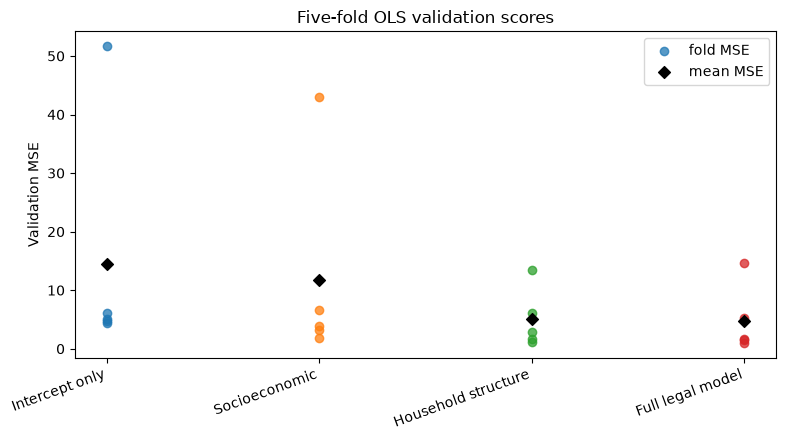

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for position, model_name in enumerate(model_specs):
    values = fold_scores.loc[fold_scores["model"] == model_name, "mse"].to_numpy()
    ax.scatter(np.full(len(values), position), values, alpha=0.75, label="fold MSE" if position == 0 else None)
    ax.scatter(position, values.mean(), marker="D", color="black", zorder=3, label="mean MSE" if position == 0 else None)
ax.set_xticks(range(len(model_specs)), model_specs, rotation=20, ha="right")
ax.set_ylabel("Validation MSE")
ax.set_title("Five-fold OLS validation scores")
ax.legend()
fig.tight_layout()

## A target-leakage warning

Now we intentionally fit an invalid model that adds `violent`. The dataset defines violent crime as a rate that includes murder, so this predictor contains information from the target. The code still performs the folds correctly; the problem is the data definition, not the splitting algorithm.

In [6]:
leaky_variables = [*predictors, "violent"]
leaky_mse = cross_validate_ols(data, target, leaky_variables, folds)
leaky_summary = pd.DataFrame(
    {
        "model": ["Invalid: includes violent"],
        "mean_mse": [leaky_mse.mean()],
        "std_mse": [leaky_mse.std(ddof=1)],
    }
)
pd.concat([summary, leaky_summary], ignore_index=True)

,model,mean_mse,std_mse
0,Intercept only,14.392368,20.851558
1,Socioeconomic,11.699279,17.558921
2,Household structure,5.024984,5.058611
3,Full legal model,4.795125,5.707941
4,Invalid: includes violent,4.240788,4.993137


The invalid model may look attractive because `violent` is closely related to `murder`. That does not make it a valid forecasting model: at prediction time, a variable that already includes the outcome would not be available without using the outcome itself. Cross-validation cannot detect this kind of target leakage automatically.

## Model selection is not final evaluation

The legal model with the smallest mean CV MSE is selected using the same scores that were just inspected. This is appropriate for choosing a candidate, but the minimum score is no longer an untouched estimate of future performance: among several candidates, random fold noise tends to favor the one that happened to look best.

For a final performance claim, reserve an independent test set or use nested cross-validation. This notebook focuses on the selection step, so it does not present the selected CV score as an unbiased final estimate.

In [7]:
selected_model = summary.loc[summary["mean_mse"].idxmin(), "model"]
print(f"Selected legal candidate by mean CV MSE: {selected_model}")

Selected legal candidate by mean CV MSE: Full legal model


## Takeaways

- Keep the validation fold separate from model fitting.
- Reuse the same folds when comparing candidate models.
- Check how every predictor is defined; cross-validation does not prevent target leakage.
- Treat the best score used for selection as optimistic until it is checked with an independent test set or nested cross-validation.